In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [65]:
files = {
	# ===== DeBERTa 512 =====
	"deberta_42":     "deberta_processed/deberta_seed_42_processed/submission_seed42.csv",
	"deberta_1337":   "deberta_processed/deberta_seed_1337_processed/submission_seed_daberta_processed1337.csv",
	"deberta_2024":   "deberta_processed/deberta_seed_2024_processed/submission_seed_daberta_processed2024.csv",
	"deberta_noseed": "deberta_processed/submission_deberta_processed_noseed.csv",

	# ===== DeBERTa 256 =====
	"deberta256_noseed": "deberta_MAXLEN256/submission_deberta_processed_noseed_MAXLEN_256.csv",
    "deberta256_42" :  "deberta_MAXLEN256/deberta_seed42_MAXLEN256\submission_roberta_processed_seed42_MAXLEN256.csv",
    "deberta256_1337" : "deberta_MAXLEN256/deberta_seed1337_MAXLEN256/submission_roberta_processed_seed1337_MAXLEN256.csv",
    "deberta256_2024" : "deberta_MAXLEN256/deberta_seed2024_MAXLEN256/submission_roberta_processed_seed2024_MAXLEN256.csv",

	# ===== RoBERTa 512 =====
	"roberta_42":     "roberta_processed/roberta_processed_seed_42/submission_seed_roberta_processed42.csv",
	"roberta_1337":   "roberta_processed/roberta_processed_seed_1337/submission_seed_roberta_processed1337.csv",
	"roberta_2024":   "roberta_processed/roberta_processed_seed_2024/submission_seed_roberta_processed2024.csv",
	"roberta_noseed": "roberta_processed/submission_roberta_full_noseed_processed.csv",

	# ===== RoBERTa 256 =====
	"roberta256_42":   "roberta_MAXLEN256/roberta_seed42_MAXLEN256/submission_roberta_processed_seed42_MAXLEN256.csv",
	"roberta256_1337": "roberta_MAXLEN256/roberta_seed1337_MAXLEN256/submission_roberta_processed_seed1337_MAXLEN256.csv",
	"roberta256_2024": "roberta_MAXLEN256/roberta_seed2024_MAXLEN256/submission_roberta_processed_seed2024_MAXLEN256.csv",
    "roberta_256_noseed" : "roberta_MAXLEN256/submission_roberta_processed_noseed_MAXLEN_256.csv"
}



In [66]:
preds = {}
ids_ref = None

for name, path in files.items():
	df = pd.read_csv(path)
	assert {"Id", "Predicted"}.issubset(df.columns)

	if ids_ref is None:
		ids_ref = df["Id"].values
	else:
		assert np.all(df["Id"].values == ids_ref), f"ID mismatch in {name}"

	preds[name] = df["Predicted"].values

print(f"Loaded {len(preds)} models | {len(ids_ref)} samples")



Loaded 16 models | 20000 samples


In [67]:
models = list(preds.keys())
n = len(models)
overlap = np.zeros((n, n))

for i, m1 in enumerate(models):
	for j, m2 in enumerate(models):
		overlap[i, j] = np.mean(preds[m1] == preds[m2])

overlap_df = pd.DataFrame(overlap, index=models, columns=models)
overlap_df.to_csv("overlap_matrix.csv")


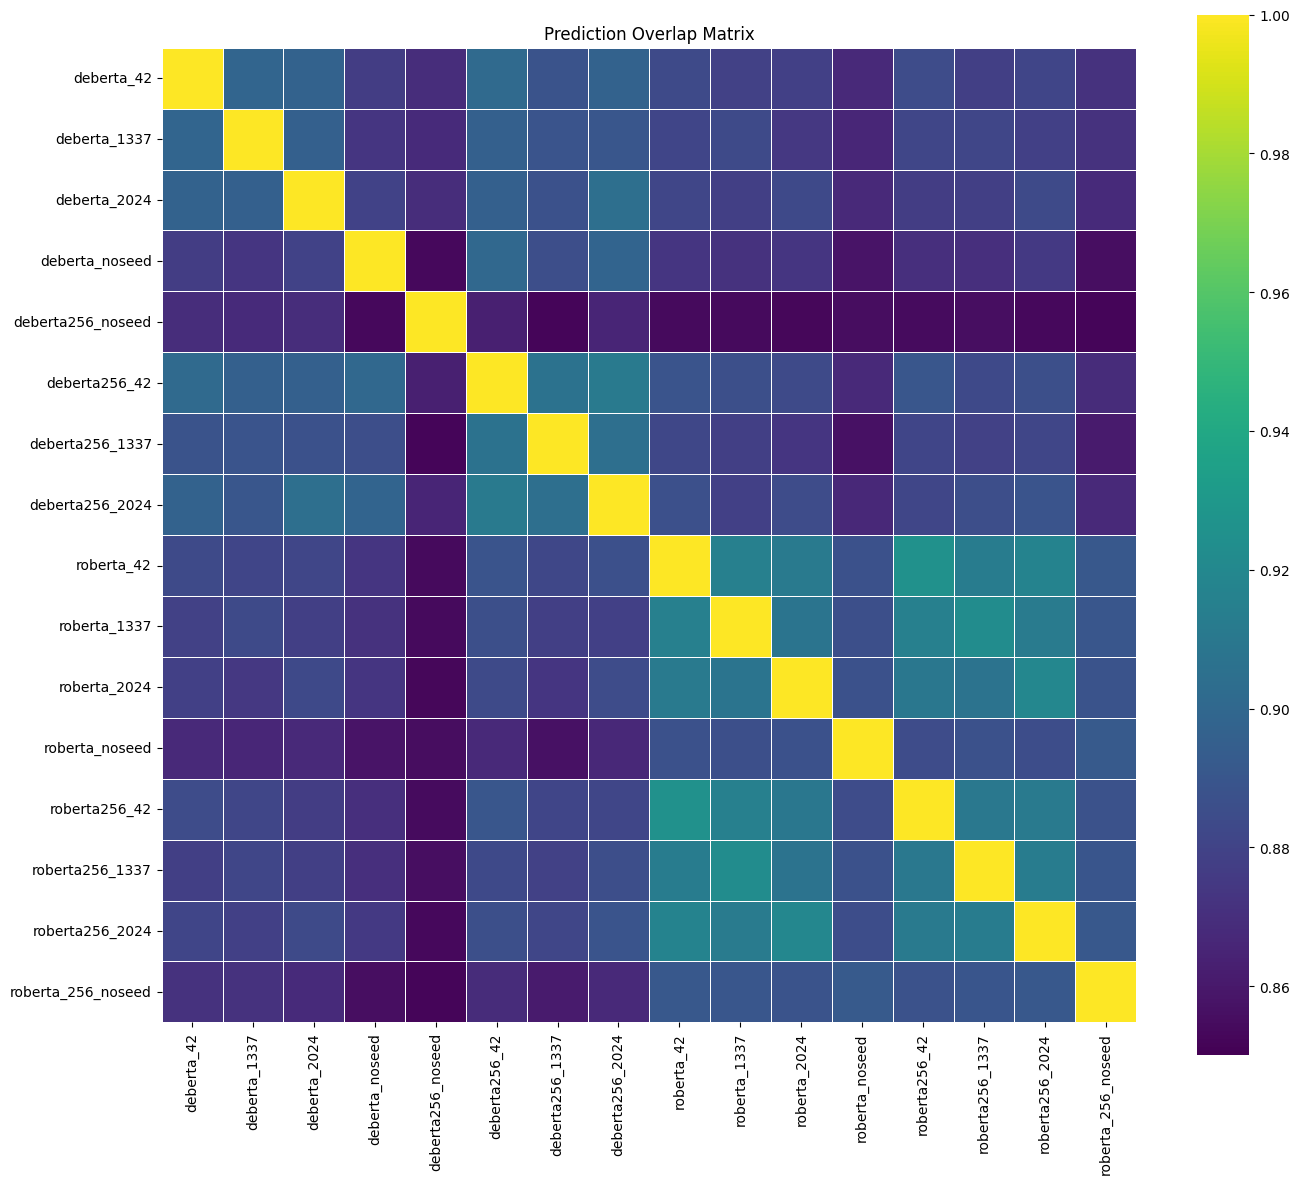

In [68]:
plt.figure(figsize=(14, 12))
sns.heatmap(
	overlap_df,
	cmap="viridis",
	vmin=0.85,
	vmax=1.0,
	square=True,
	linewidths=0.5
)
plt.title("Prediction Overlap Matrix")
plt.tight_layout()
plt.savefig("overlap_matrix.png", dpi=300)
plt.show()


In [69]:
def disagreement(model_list):
	mat = np.stack([preds[m] for m in model_list])
	mode = np.apply_along_axis(
		lambda x: np.bincount(x).argmax(), axis=0, arr=mat
	)
	return np.mean(mat != mode)

deberta_models = [m for m in models if "deberta" in m]
roberta_models = [m for m in models if "roberta" in m]

print("DeBERTa disagreement:", round(disagreement(deberta_models), 5))
print("RoBERTa disagreement:", round(disagreement(roberta_models), 5))


DeBERTa disagreement: 0.07296
RoBERTa disagreement: 0.06307


In [71]:
all_preds = np.stack([preds[m] for m in models])

def is_hard(col):
	counts = np.bincount(col)
	return counts.max() < (len(models) / 2)

hard_mask = np.apply_along_axis(is_hard, axis=0, arr=all_preds)
hard_indices = np.where(hard_mask)[0]

print(f"Hard cases: {len(hard_indices)} / {len(ids_ref)}")


Hard cases: 238 / 20000


In [72]:
hard_df = pd.DataFrame({
	"Id": ids_ref[hard_indices]
})
hard_df.to_csv("hard_cases_ids.csv", index=False)


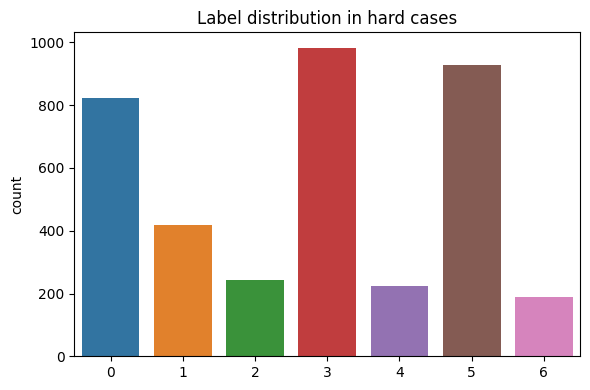

In [73]:
hard_preds = all_preds[:, hard_indices].flatten()

plt.figure(figsize=(6,4))
sns.countplot(x=hard_preds)
plt.title("Label distribution in hard cases")
plt.tight_layout()
plt.savefig("hard_cases_label_distribution.png", dpi=300)
plt.show()


In [74]:
all_preds = np.stack([preds[m] for m in models])

def is_hard(col):
	counts = np.bincount(col)
	return counts.max() < (len(models) / 2)

hard_mask = np.apply_along_axis(is_hard, axis=0, arr=all_preds)
hard_indices = np.where(hard_mask)[0]

print(f"Hard cases: {len(hard_indices)} / {len(ids_ref)}")


Hard cases: 238 / 20000


In [75]:
model_names = list(preds.keys())
overlap = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for m1 in model_names:
	for m2 in model_names:
		overlap.loc[m1, m2] = np.mean(preds[m1] == preds[m2])

overlap = overlap.astype(float)
overlap





,deberta_42,deberta_1337,deberta_2024,deberta_noseed,deberta256_noseed,deberta256_42,deberta256_1337,deberta256_2024,roberta_42,roberta_1337,roberta_2024,roberta_noseed,roberta256_42,roberta256_1337,roberta256_2024,roberta_256_noseed
deberta_42,1.00000,0.89820,0.89665,0.87665,0.86895,0.90110,0.88860,0.89680,0.88390,0.87895,0.87815,0.86730,0.88450,0.87760,0.88055,0.87130
deberta_1337,0.89820,1.00000,0.89555,0.87290,0.86810,0.89520,0.88905,0.89025,0.88095,0.88340,0.87435,0.86620,0.88120,0.88145,0.87840,0.87130
deberta_2024,0.89665,0.89555,1.00000,0.87965,0.86920,0.89555,0.88710,0.90440,0.88130,0.87790,0.88335,0.86710,0.87655,0.87790,0.88345,0.86760
deberta_noseed,0.87665,0.87290,0.87965,1.00000,0.85305,0.90020,0.88550,0.89750,0.87290,0.87115,0.87300,0.85790,0.87005,0.87015,0.87510,0.85575
deberta256_noseed,0.86895,0.86810,0.86920,0.85305,1.00000,0.86295,0.85215,0.86550,0.85385,0.85360,0.85280,0.85480,0.85420,0.85570,0.85300,0.85205
deberta256_42,0.90110,0.89520,0.89555,0.90020,0.86295,1.00000,0.90670,0.91095,0.88880,0.88605,0.88345,0.86700,0.88985,0.88300,0.88625,0.86830
deberta256_1337,0.88860,0.88905,0.88710,0.88550,0.85215,0.90670,1.00000,0.90415,0.88220,0.87805,0.87305,0.85650,0.88070,0.87905,0.88135,0.86060
deberta256_2024,0.89680,0.89025,0.90440,0.89750,0.86550,0.91095,0.90415,1.00000,0.88665,0.87830,0.88450,0.86675,0.88140,0.88520,0.88875,0.86720
roberta_42,0.88390,0.88095,0.88130,0.87290,0.85385,0.88880,0.88220,0.88665,1.00000,0.91495,0.91110,0.88715,0.92550,0.91235,0.91690,0.89100
roberta_1337,0.87895,0.88340,0.87790,0.87115,0.85360,0.88605,0.87805,0.87830,0.91495,1.00000,0.90795,0.88585,0.91465,0.92220,0.91195,0.89035


In [76]:
overlap.to_csv("overlap_matrix.txt", sep="\t", float_format="%.6f")


In [ ]:
preds = load_predictions(files)


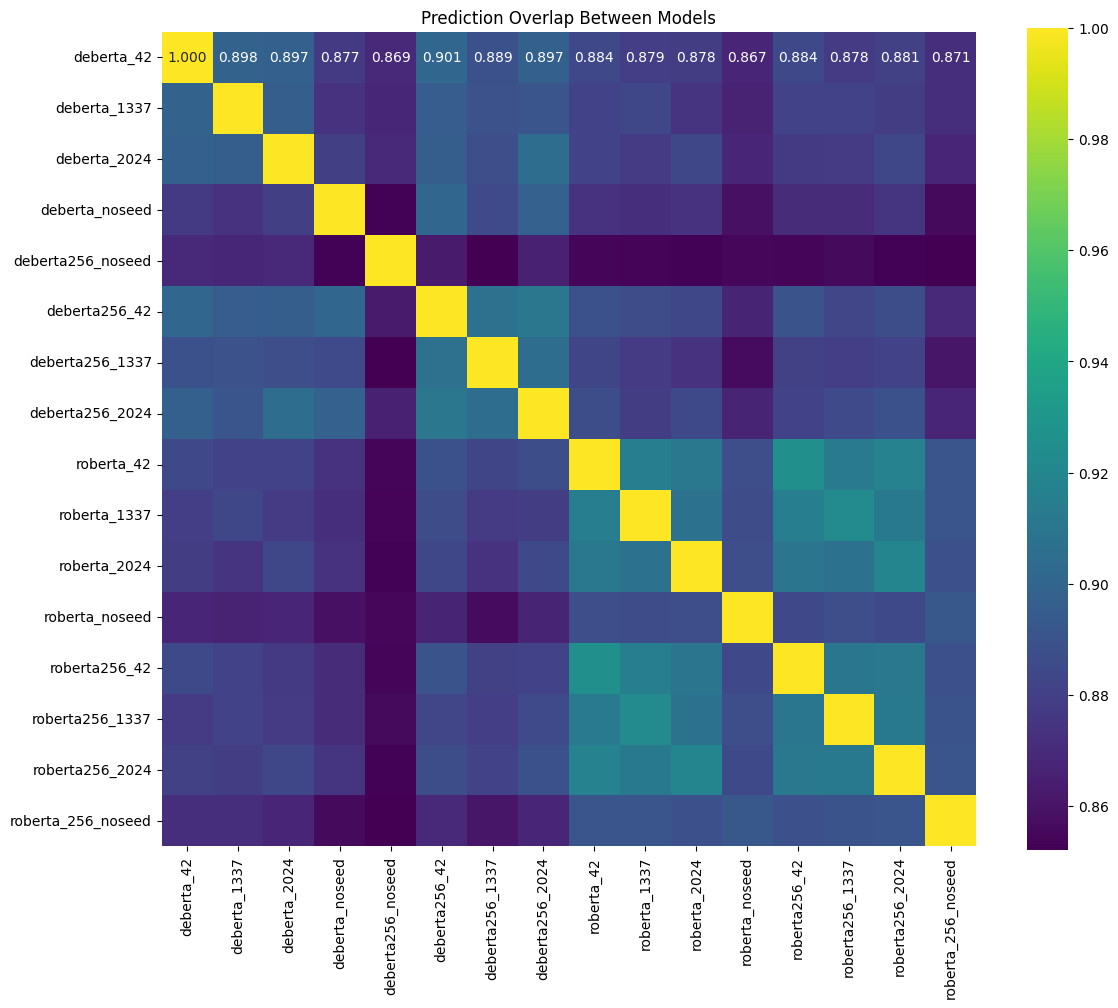

In [77]:
plt.figure(figsize=(12, 10))
sns.heatmap(
	overlap,
	annot=True,
	fmt=".3f",
	cmap="viridis",
	square=True
)
plt.title("Prediction Overlap Between Models")
plt.tight_layout()
plt.show()


In [59]:
def disagreement_rate(models):
	mat = np.stack([preds[m] for m in models])
	# percentuale di sample dove NON tutti concordano
	return np.mean(np.std(mat, axis=0) > 0)

models_deberta = [m for m in preds if m.startswith("deberta")]
models_roberta = [m for m in preds if m.startswith("roberta")]

print("DeBERTa disagreement:", disagreement_rate(models_deberta))
print("RoBERTa disagreement:", disagreement_rate(models_roberta))


DeBERTa disagreement: 0.26945
RoBERTa disagreement: 0.2321


In [78]:
if "deberta_noseed" in preds and "deberta256_noseed" in preds:
	print(
		"DeBERTa 512 vs 256 overlap:",
		np.mean(preds["deberta_noseed"] == preds["deberta256_noseed"])
	)



DeBERTa 512 vs 256 overlap: 0.85305


In [ ]:
rows = []

for seed in [42, 1337, 2024]:
	m512 = f"roberta_{seed}"
	m256 = f"roberta256_{seed}"
	if m512 in preds and m256 in preds:
		rows.append({
			"seed": seed,
			"overlap": np.mean(preds[m512] == preds[m256])
		})

pd.DataFrame(rows)



In [ ]:
K = int(len(preds) * 0.4)  # soglia regolabile

all_preds = np.stack(list(preds.values()))
hard_mask = np.apply_along_axis(lambda x: len(set(x)) >= K, 0, all_preds)

hard_ids = np.where(hard_mask)[0]

print(f"Hard cases: {len(hard_ids)} / {N}")
hard_ids[:20]



In [ ]:
from scipy.stats import mode

ensemble_pred, _ = mode(all_preds, axis=0)
ensemble_pred = ensemble_pred.flatten()

print("Ensemble ready:", ensemble_pred.shape)


In [ ]:
compare_512_vs_256(preds)


In [ ]:
def disagreement_rate(preds, keys):
	stack = np.vstack([preds[k] for k in keys])
	return np.mean(np.std(stack, axis=0) > 0)


In [60]:
models_deberta = [k for k in preds if k.startswith("deberta_")]
models_roberta = [k for k in preds if k.startswith("roberta_") and "256" not in k]

print("DeBERTa disagreement:", disagreement_rate(preds, models_deberta))
print("RoBERTa disagreement:", disagreement_rate(preds, models_roberta))


TypeError: disagreement_rate() takes 1 positional argument but 2 were given

In [61]:
def hard_cases(preds, keys):
	stack = np.vstack([preds[k] for k in keys])
	return np.where(np.std(stack, axis=0) > 0)[0]


In [62]:
hard_idx = hard_cases(preds, models_deberta + models_roberta)
len(hard_idx)


5388

In [63]:
def majority_vote(model_list):
	mat = np.vstack([preds[m] for m in model_list])
	out = []
	for col in mat.T:
		out.append(Counter(col).most_common(1)[0][0])
	return np.array(out)

ensemble_linear = majority_vote(models)

pd.DataFrame({
	"Id": ids_ref,
	"Label": ensemble_linear
}).to_csv("submission_ensemble_majority.csv", index=False)


NameError: name 'models' is not defined

In [79]:
def disagreement(model_list):
	mat = np.stack([preds[m] for m in model_list])
	mode = np.apply_along_axis(
		lambda x: np.bincount(x).argmax(), axis=0, arr=mat
	)
	return np.mean(mat != mode)
roberta_512 = [m for m in models if "roberta_" in m and "256" not in m]
roberta_256 = [m for m in models if "roberta256" in m or "roberta_256" in m]

print("RoBERTa 512 disagreement:", round(disagreement(roberta_512), 5))
print("RoBERTa 256 disagreement:", round(disagreement(roberta_256), 5))


RoBERTa 512 disagreement: 0.0588
RoBERTa 256 disagreement: 0.05836


In [80]:
deberta_512 = [m for m in models if "deberta_" in m and "256" not in m]
deberta_256 = [m for m in models if "deberta256" in m]

print("DeBERTa 512 disagreement:", round(disagreement(deberta_512), 5))
print("DeBERTa 256 disagreement:", round(disagreement(deberta_256), 5))


DeBERTa 512 disagreement: 0.06623
DeBERTa 256 disagreement: 0.06708


In [81]:
def pairwise_disagreement(group_a, group_b):
	mat_a = np.stack([preds[m] for m in group_a])
	mat_b = np.stack([preds[m] for m in group_b])

	# confronto tutte le coppie
	dis = []
	for i in range(mat_a.shape[0]):
		for j in range(mat_b.shape[0]):
			dis.append(np.mean(mat_a[i] != mat_b[j]))
	return np.mean(dis)

print(
	"RoBERTa 256 vs 512 disagreement:",
	round(pairwise_disagreement(roberta_256, roberta_512), 5)
)


RoBERTa 256 vs 512 disagreement: 0.09644


In [82]:
print(
	"DeBERTa 256 vs 512 disagreement:",
	round(pairwise_disagreement(deberta_256, deberta_512), 5)
)


DeBERTa 256 vs 512 disagreement: 0.11309


In [83]:
print(
	"Cross-arch (256):",
	round(pairwise_disagreement(roberta_256, deberta_256), 5)
)


Cross-arch (256): 0.12709


In [84]:
print(
	"Cross-arch (512):",
	round(pairwise_disagreement(roberta_512, deberta_512), 5)
)


Cross-arch (512): 0.12514
